# Пошук викидів та аномалій

## 1. Вступ

### Що таке викиди?

**Викид** - це точка даних, яка значно відрізняється від інших спостережень у наборі даних. Викиди можуть бути:

- **Точкові**: Окремі точки даних, які є аномальними
- **Контекстні**: Нормальні в одному контексті, але аномальні в іншому
- **Колективні**: Колекція точок даних, які є аномальними як група

### Викиди vs Шум

Важливо розрізняти викиди та шум:

| **Викиди** | **Шум** |
|------------|---------|
| Значущі відхилення від патерну | Випадкові помилки або неточності вимірювання |
| Можуть містити цінну інформацію | Слід видалити або виправити |
| Можуть вказувати на шахрайство, помилки або рідкісні події | Спотворює справжній сигнал |
| Варто дослідити | Варто відфільтрувати |

### Навіщо виявляти викиди?

1. **Якість даних**: Ідентифікувати помилки в зборі даних
2. **Безпека**: Виявляти шахрайські дії
3. **Моніторинг систем**: Ідентифікувати відмови обладнання або незвичайну поведінку
4. **Наукові відкриття**: Знаходити рідкісні явища або нові патерни
5. **Якість моделі**: Покращити точність моделей машинного навчання

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.style.use('default')
sns.set_palette("husl")

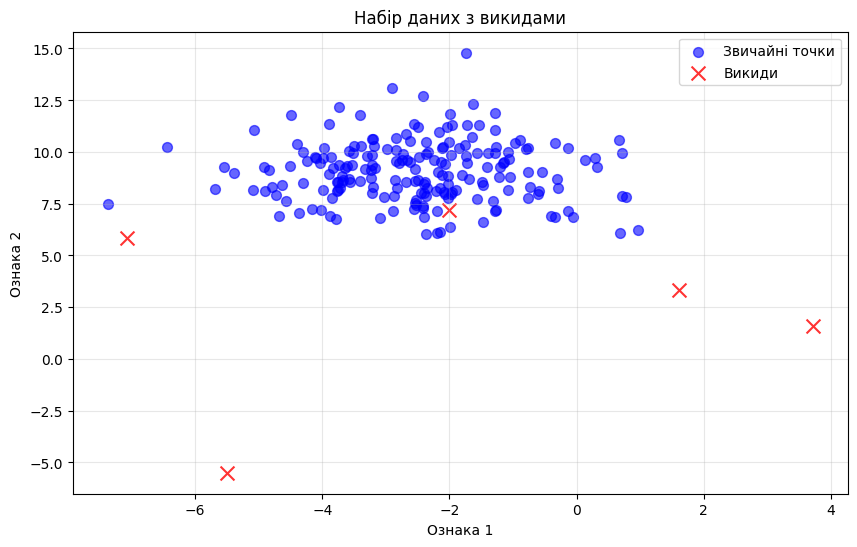

Розмірність датасету: (205, 2)
Кількість звичайних точок: 200
Кількість викидів: 5


In [4]:
def create_sample_data():
    normal_data, _ = make_blobs(n_samples=200, centers=1, cluster_std=1.5, random_state=42)
    outliers = np.random.uniform(-8, 8, (5, 2))
    X = np.vstack([normal_data, outliers])
    y = np.hstack([np.zeros(200), np.ones(5)])  
    return X, y

X, y = create_sample_data()

plt.figure(figsize=(10, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', alpha=0.6, label='Звичайні точки', s=50)
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', alpha=0.8, label='Викиди', s=100, marker='x')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.title('Набір даних з викидами')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Розмірність датасету: {X.shape}")
print(f"Кількість звичайних точок: {np.sum(y==0)}")
print(f"Кількість викидів: {np.sum(y==1)}")

## 2. Статистичні методи пошуку викидів

Статистичні методи - найпростіші та найінтуїтивніші підходи до виявлення викидів. Вони добре працюють для одновимірних даних та припускають, що дані розподілені за певним розподілом, часто нормальним.

### Z-статистика (Z-score)

**Z-статистика** вимірює, на яку кількість стандартних відхилень точка даних відхиляється від середнього:

$$z = \frac{x - \mu}{\sigma}$$

Де:
- $x$ - точка даних
- $\mu$ - середнє
- $\sigma$ - стандартне відхилення

**Поріг**: Точки з $|z| > 3$ зазвичай вважаються викидами.

![Z-scores](images/11.0-z-scores.png)

[Джерело зображення](https://www.analyticsvidhya.com/blog/2022/08/dealing-with-outliers-using-the-z-score-method/)


### Метод міжквартильного розмаху (interquartile range, IQR)

1. Обчислити Q1 (25-й перцентиль) та Q3 (75-й перцентиль)
2. Обчислити IQR = Q3 - Q1
3. Визначити межі викидів:
   - Нижня межа = Q1 - 1.5 × IQR
   - Верхня межа = Q3 + 1.5 × IQR

Точки поза цими межами вважаються викидами.

![IQR](images/11.1-iqr.png)

[Джерело зображення](https://www.analyticsvidhya.com/blog/2022/10/outliers-detection-using-iqr-z-score-lof-and-dbscan/)

Результати статистичного виявлення викидів (за обома ознаками):
Метод Z-оцінки виявив 7 викидів
Метод IQR виявив 7 викидів
Справжня кількість викидів у датасеті: 5


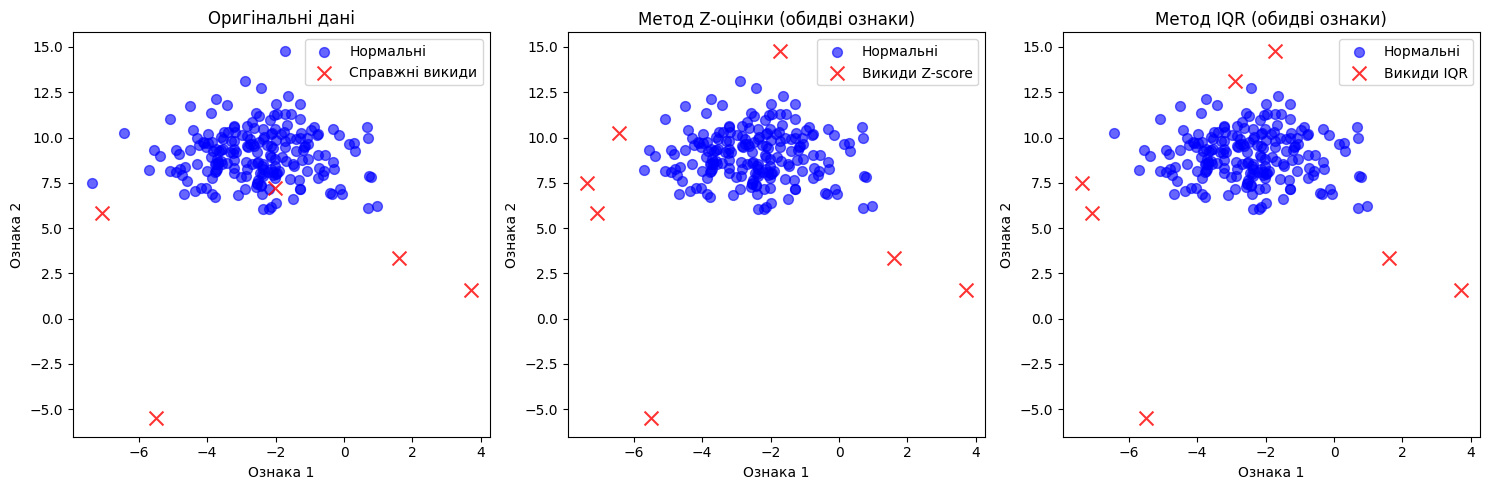

In [5]:
def z_score_outlier_detection_multivariate(data, threshold=3):
    z_scores = np.abs((data - np.mean(data, axis=0)) / np.std(data, axis=0))
    return np.any(z_scores > threshold, axis=1)

def iqr_outlier_detection_multivariate(data):
    Q1 = np.percentile(data, 25, axis=0)
    Q3 = np.percentile(data, 75, axis=0)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (data < lower_bound) | (data > upper_bound)
    return np.any(outliers, axis=1)

features = X

z_outliers_multi = z_score_outlier_detection_multivariate(features, threshold=2.5)

iqr_outliers_multi = iqr_outlier_detection_multivariate(features)

print("Результати статистичного виявлення викидів (за обома ознаками):")
print(f"Метод Z-оцінки виявив {np.sum(z_outliers_multi)} викидів")
print(f"Метод IQR виявив {np.sum(iqr_outliers_multi)} викидів")
print(f"Справжня кількість викидів у датасеті: {np.sum(y==1)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X[y == 0, 0], X[y == 0, 1], c='blue', alpha=0.6, label='Нормальні', s=50)
axes[0].scatter(X[y == 1, 0], X[y == 1, 1], c='red', alpha=0.8, label='Справжні викиди', s=100, marker='x')
axes[0].set_title('Оригінальні дані')
axes[0].legend()
axes[0].set_xlabel('Ознака 1')
axes[0].set_ylabel('Ознака 2')

axes[1].scatter(X[~z_outliers_multi, 0], X[~z_outliers_multi, 1], c='blue', alpha=0.6, label='Нормальні', s=50)
axes[1].scatter(X[z_outliers_multi, 0], X[z_outliers_multi, 1], c='red', alpha=0.8, label='Викиди Z-score', s=100, marker='x')
axes[1].set_title('Метод Z-оцінки (обидві ознаки)')
axes[1].legend()
axes[1].set_xlabel('Ознака 1')
axes[1].set_ylabel('Ознака 2')

axes[2].scatter(X[~iqr_outliers_multi, 0], X[~iqr_outliers_multi, 1], c='blue', alpha=0.6, label='Нормальні', s=50)
axes[2].scatter(X[iqr_outliers_multi, 0], X[iqr_outliers_multi, 1], c='red', alpha=0.8, label='Викиди IQR', s=100, marker='x')
axes[2].set_title('Метод IQR (обидві ознаки)')
axes[2].legend()
axes[2].set_xlabel('Ознака 1')
axes[2].set_ylabel('Ознака 2')

plt.tight_layout()
plt.show()

## 3. Методи на основі відстані

Методи на основі відстані ідентифікують викиди, вимірюючи відстань між точками даних. Ключове припущення полягає в тому, що викиди знаходяться далеко від більшості інших точок у наборі даних.

### Відстань k-найближчих сусідів (k-NN)

Метод відстані k-NN обчислює відстань до k-го найближчого сусіда для кожної точки. Точки з великими відстанями k-NN вважаються викидами.

**Алгоритм:**
1. Для кожної точки даних знайти її k найближчих сусідів
2. Обчислити відстань до k-го найближчого сусіда
3. Точки з відстанями вище порогу є викидами

**Переваги:**
- Працює з багатовимірними даними
- Непараметричний (немає припущень про розподіл)
- Може виявляти викиди у будь-якій формі даних

**Недоліки:**
- Чутливий до вибору k
- Обчислювально дорогий для великих наборів даних

Результати методу відстаней k-NN:
Метод k-NN виявив 5 викидів
Порогова відстань: 2.942


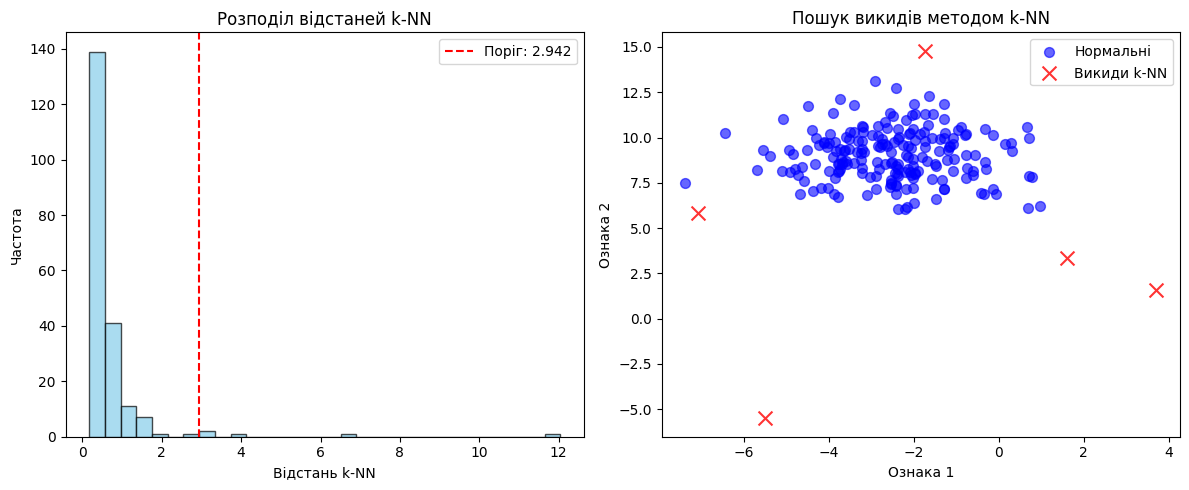


Порівняння з істинними викидами:
Істинних викидів: 5
Виявлено k-NN: 5
Перетин: 4


In [6]:
from sklearn.neighbors import NearestNeighbors

def knn_outlier_detection(X, k=5, threshold_percentile=95):
    nbrs = NearestNeighbors(n_neighbors=k+1)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    kth_distances = distances[:, k]
    threshold = np.percentile(kth_distances, threshold_percentile)
    outliers = kth_distances > threshold
    return outliers, kth_distances, threshold

knn_outliers, knn_distances, knn_threshold = knn_outlier_detection(X, k=5, threshold_percentile=98)

print("Результати методу відстаней k-NN:")
print(f"Метод k-NN виявив {np.sum(knn_outliers)} викидів")
print(f"Порогова відстань: {knn_threshold:.3f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(knn_distances, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(knn_threshold, color='red', linestyle='--', label=f'Поріг: {knn_threshold:.3f}')
plt.xlabel('Відстань k-NN')
plt.ylabel('Частота')
plt.title('Розподіл відстаней k-NN')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X[~knn_outliers, 0], X[~knn_outliers, 1], c='blue', alpha=0.6, label='Нормальні', s=50)
plt.scatter(X[knn_outliers, 0], X[knn_outliers, 1], c='red', alpha=0.8, label='Викиди k-NN', s=100, marker='x')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.title('Пошук викидів методом k-NN')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nПорівняння з істинними викидами:")
print(f"Істинних викидів: {np.sum(y==1)}")
print(f"Виявлено k-NN: {np.sum(knn_outliers)}")
print(f"Перетин: {np.sum(knn_outliers & (y==1))}")

## 4. Методи на основі щільності

Методи на основі щільності ідентифікують викиди, порівнюючи локальну щільність точки з щільністю її сусідів. Ключова ідея полягає в тому, що викиди мають значно нижчу щільність, ніж їх сусіди.

### Фактор локальних викидів (Local outlier factor, LOF)

**Фактор локальних викидів (LOF)** — один із найпопулярніших методів виявлення викидів на основі щільності.

**Ключові концепції:**

1. **k-відстань** — відстань до k-го найближчого сусіда.

2. **Відстань досяжності**:
   $$
   RD_k(A, B) = \max\left\{k\text{-відстань}(B),\ d(A, B)\right\}
   $$
   - $A, B$ — точки у вибірці
   - $d(A, B)$ — відстань між точками $A$ і $B$ (наприклад, евклідова)
   - $k\text{-відстань}(B)$ — відстань від $B$ до її $k$-го найближчого сусіда

3. **Щільність локальної досяжності (LRD)**:
   $$
   LRD_k(A) = \frac{|N_k(A)|}{\sum\limits_{B \in N_k(A)} RD_k(A, B)}
   $$
   - $N_k(A)$ — множина $k$ найближчих сусідів точки $A$
   - $|N_k(A)|$ — кількість елементів у множині сусідів, тобто $k$
   - $RD_k(A, B)$ — відстань досяжності між $A$ та $B$

4. **Фактор локальних викидів**:
   $$
   LOF_k(A) = \frac{1}{|N_k(A)|}\sum\limits_{B \in N_k(A)} \frac{LRD_k(B)}{LRD_k(A)}
   $$
   - $LOF_k(A)$ — фактор локальних викидів для точки $A$ при фіксованому $k$
   - $LRD_k(B)$ — локальна щільність досяжності для сусіда $B$

**Інтерпретація:**
- LOF ≈ 1: Точка має подібну щільність до своїх сусідів (нормальна точка)
- LOF > 1: Точка має нижчу щільність, ніж її сусіди (викид)
- LOF ≫ 1: Сильний викид

**Вибір k для LOF:**
- Занадто малий k: Може не відображати локальну щільність правильно
- Занадто великий k: Може пропустити локальні викиди

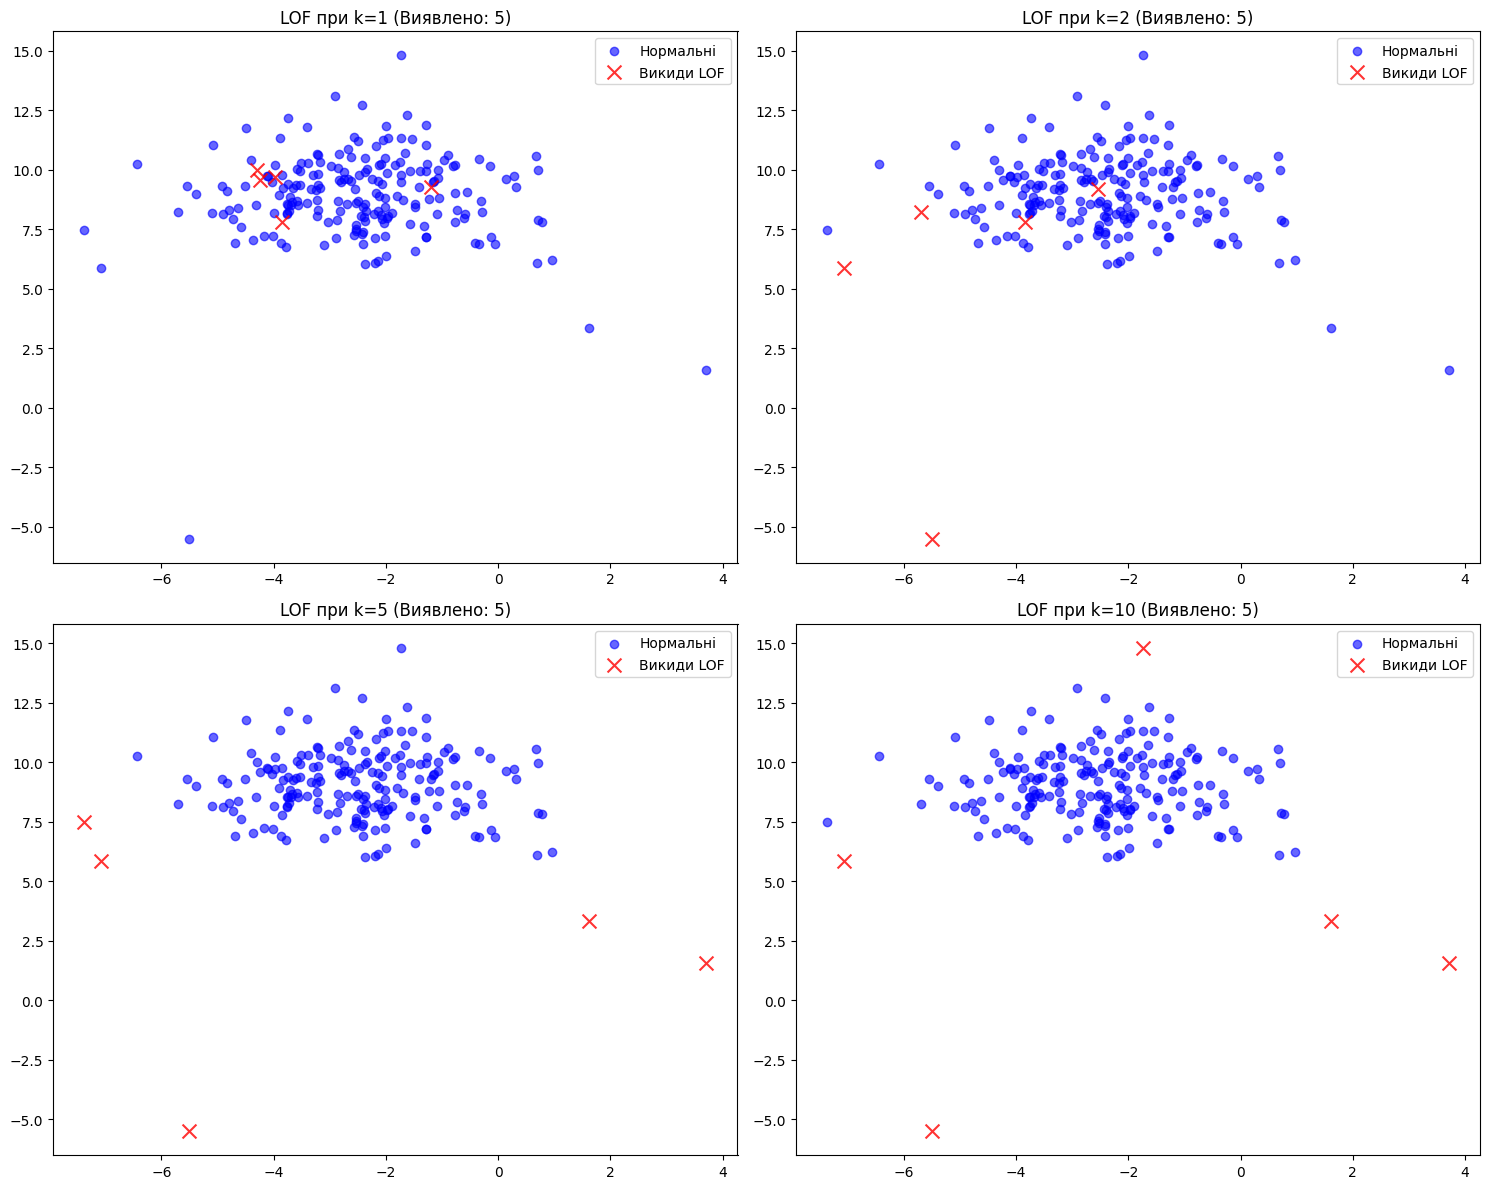

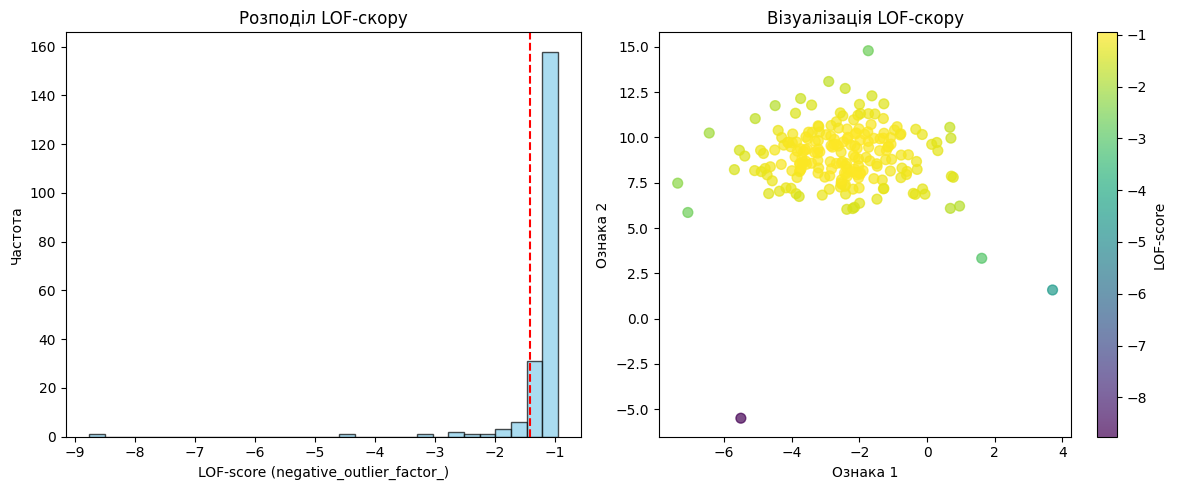

Результати методу LOF:
Метод LOF виявив 5 викидів
Істинних викидів: 5
Перетин: 4


In [10]:
def lof_outlier_detection(X, k=20, contamination=0.05):
    lof = LocalOutlierFactor(n_neighbors=k, contamination=contamination)
    outlier_labels = lof.fit_predict(X)
    lof_scores = lof.negative_outlier_factor_
    outliers = outlier_labels == -1
    return outliers, lof_scores

k_values = [1, 2, 5, 10]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, k in enumerate(k_values):
    lof_outliers, lof_scores = lof_outlier_detection(X, k=k, contamination=0.02)
    axes[i].scatter(X[~lof_outliers, 0], X[~lof_outliers, 1], c='blue', alpha=0.6, label='Нормальні')
    axes[i].scatter(X[lof_outliers, 0], X[lof_outliers, 1], c='red', alpha=0.8, label='Викиди LOF', s=100, marker='x')
    axes[i].set_title(f'LOF при k={k} (Виявлено: {np.sum(lof_outliers)})')
    axes[i].legend()

plt.tight_layout()
plt.show()

lof_outliers_final, lof_scores_final = lof_outlier_detection(X, k=20, contamination=0.02)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(lof_scores_final, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('LOF-score (negative_outlier_factor_)')
plt.ylabel('Частота')
plt.title('Розподіл LOF-скору')
plt.axvline(np.percentile(lof_scores_final, 10), color='red', linestyle='--', label='10-й перцентиль')

plt.subplot(1, 2, 2)
scatter = plt.scatter(X[:, 0], X[:, 1], c=lof_scores_final, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='LOF-score')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.title('Візуалізація LOF-скору')

plt.tight_layout()
plt.show()

print("Результати методу LOF:")
print(f"Метод LOF виявив {np.sum(lof_outliers_final)} викидів")
print(f"Істинних викидів: {np.sum(y==1)}")
print(f"Перетин: {np.sum(lof_outliers_final & (y==1))}")

## 5. Ізоляційний ліс

**Ізоляційний ліс (Isolation Forest)** - це алгоритм виявлення аномалій на основі ансамблю дерев, який працює шляхом ізоляції викидів, а не профілювання нормальних точок.

### Як працює ізоляційний ліс

1. **Випадкове розбиття**: Створює випадкові розбиття даних, використовуючи випадкові ознаки та значення розбиття
2. **Дерева ізоляції**: Будує множину дерев ізоляції (iTrees) з випадковими розбиттями
3. **Довжина шляху**: Вимірює, скільки розбиттів потрібно для ізоляції точки
4. **Оцінка аномалії**: Точки, що вимагають менше розбиттів для ізоляції, більш ймовірно є викидами

![Isolation forest](images/11.2-isolation-forest.png)

By Sal Borrelli - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=82709489

### Ключові переваги

- **Ефективний**: Добре працює з високовимірними даними
- **Без вчителя**: Не потрібні розмічені навчальні дані
- **Масштабований**: Може обробляти великі набори даних

### Формула оцінки аномальності

Оцінка аномальності обчислюється як:

$$s(x,n) = 2^{-\frac{E(h(x))}{c(n)}}$$

Де:
- $E(h(x))$ - середня довжина шляху по всіх деревах
- $c(n)$ - середня довжина шляху невдалого пошуку в BST
- $s(x,n) \approx 1$ вказує на аномалії
- $s(x,n) \ll 1$ вказує на нормальні точки

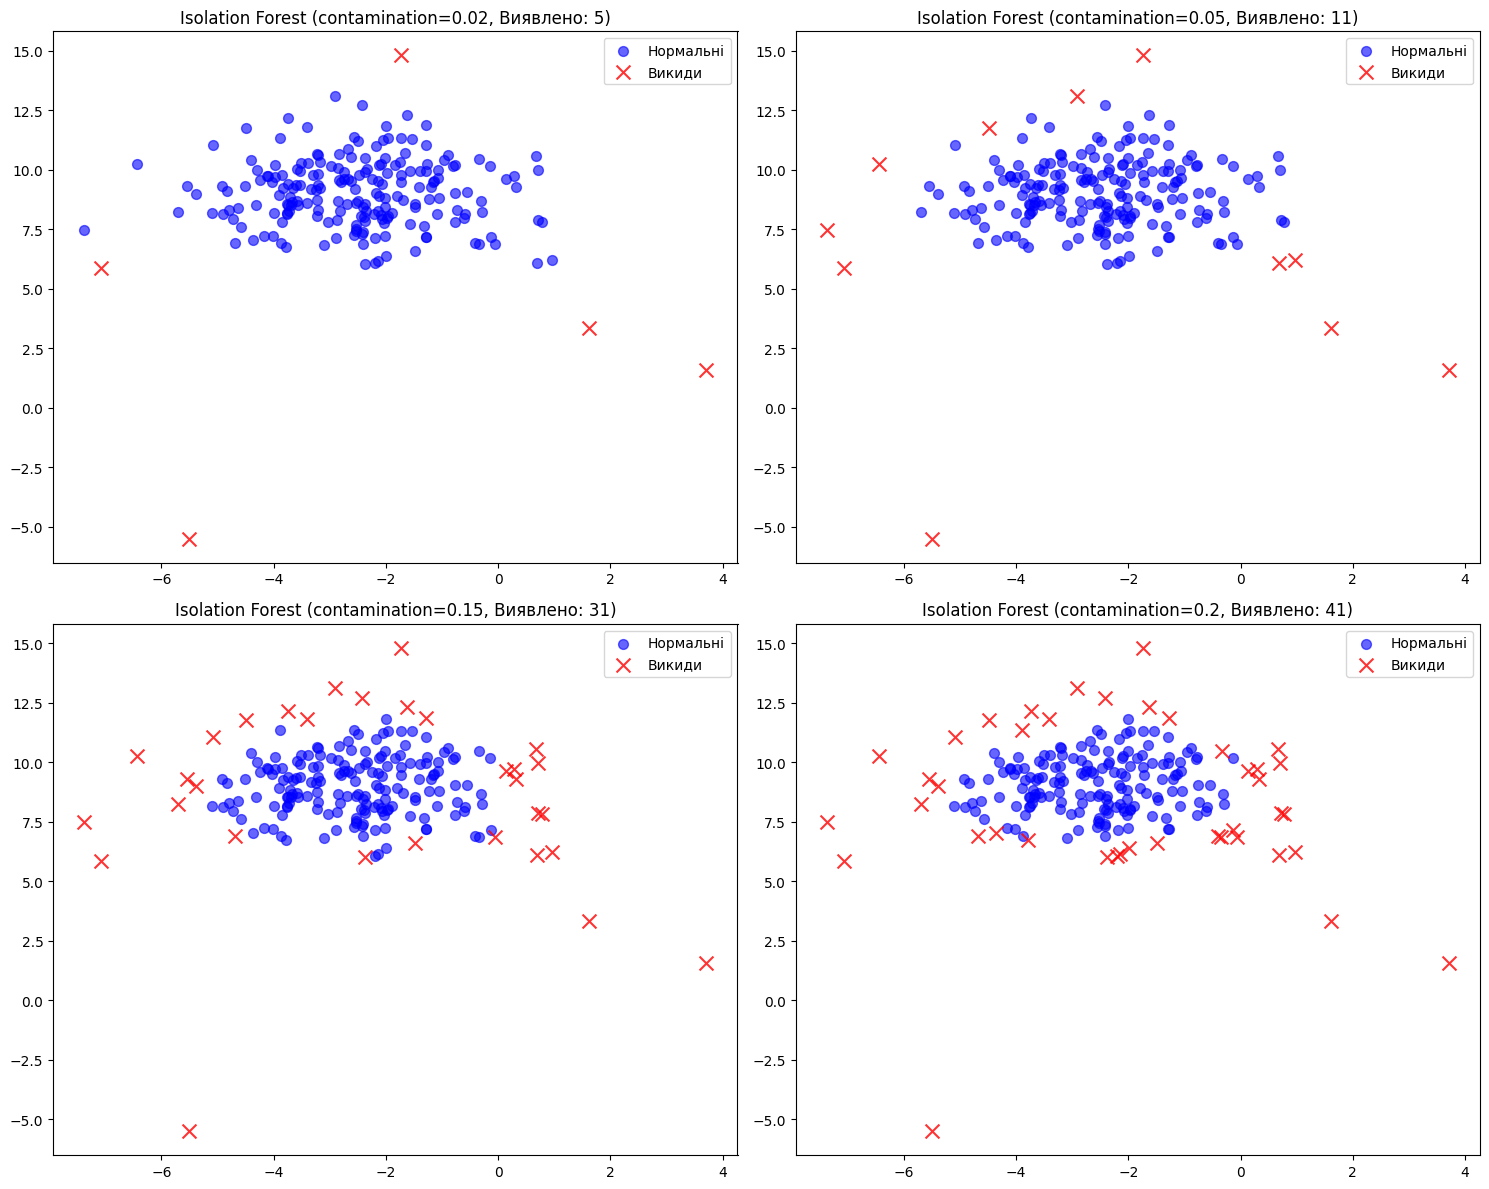

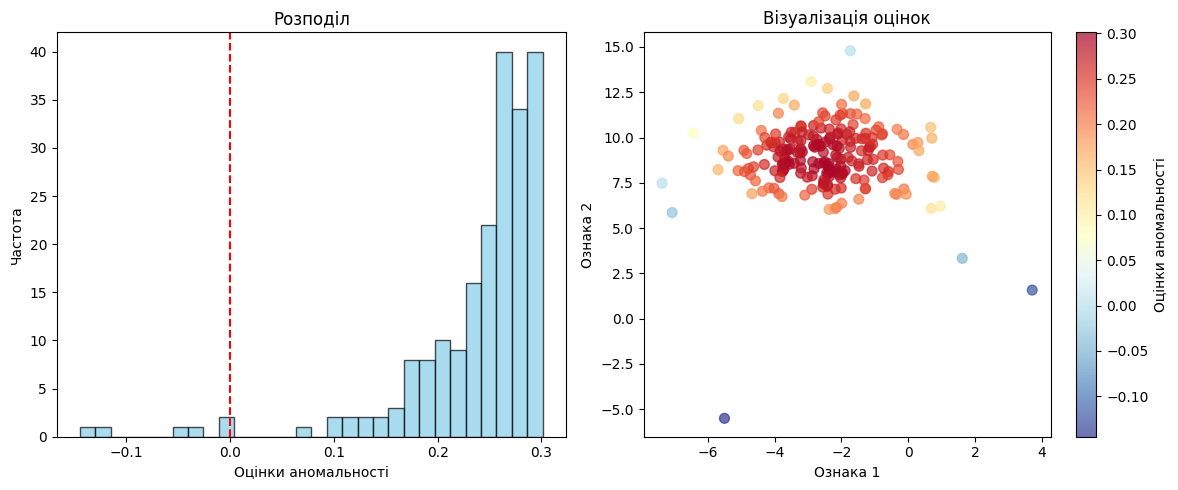

Результати Isolation Forest:
Isolation Forest виявив 5 викидів
Істинних викидів: 5
Перетин: 4

Порівняння методів:
Істинних викидів: 5
k-NN метод: 5
LOF метод: 5
Isolation Forest: 5


In [12]:
def isolation_forest_detection(X, contamination=0.1, n_estimators=100):
    iso_forest = IsolationForest(contamination=contamination, 
                                n_estimators=n_estimators, 
                                random_state=42)
    outlier_labels = iso_forest.fit_predict(X)
    anomaly_scores = iso_forest.decision_function(X)
    outliers = outlier_labels == -1
    return outliers, anomaly_scores

contamination_values = [0.02, 0.05, 0.15, 0.2]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, contamination in enumerate(contamination_values):
    iso_outliers, iso_scores = isolation_forest_detection(X, contamination=contamination)
    axes[i].scatter(X[~iso_outliers, 0], X[~iso_outliers, 1], c='blue', alpha=0.6, label='Нормальні', s=50)
    axes[i].scatter(X[iso_outliers, 0], X[iso_outliers, 1], c='red', alpha=0.8, label='Викиди', s=100, marker='x')
    axes[i].set_title(f'Isolation Forest (contamination={contamination}, Виявлено: {np.sum(iso_outliers)})')
    axes[i].legend()

plt.tight_layout()
plt.show()

iso_outliers_final, iso_scores_final = isolation_forest_detection(X, contamination=0.02)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(iso_scores_final, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Оцінки аномальності')
plt.ylabel('Частота')
plt.title('Розподіл')
plt.axvline(0, color='red', linestyle='--', label='Граница рішення (0)')

plt.subplot(1, 2, 2)
scatter = plt.scatter(X[:, 0], X[:, 1], c=iso_scores_final, cmap='RdYlBu_r', s=50, alpha=0.7)
plt.colorbar(scatter, label='Оцінки аномальності')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.title('Візуалізація оцінок')

plt.tight_layout()
plt.show()

print("Результати Isolation Forest:")
print(f"Isolation Forest виявив {np.sum(iso_outliers_final)} викидів")
print(f"Істинних викидів: {np.sum(y==1)}")
print(f"Перетин: {np.sum(iso_outliers_final & (y==1))}")

print(f"\nПорівняння методів:")
print(f"Істинних викидів: {np.sum(y==1)}")
print(f"k-NN метод: {np.sum(knn_outliers)}")
print(f"LOF метод: {np.sum(lof_outliers_final)}")
print(f"Isolation Forest: {np.sum(iso_outliers_final)}")